## Laboratorio 1 - Regresión Lineal Simple

Este laboratorio utiliza el dataset "E-Commerce Sales, Customer & Churn
(2009-2011)" obtenido de Kaggle. Contiene 17,350 registros de transacciones
de una tienda online. El objetivo es predecir el Revenue generado por
un cliente en función de su edad (Customer_Age) usando regresión lineal simple.

In [ ]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/SIS420/DataSet.xlsx')
data = df.to_numpy()
X, y = data[:, 0], data[:, 1]
m = y.size


In [ ]:
print(data)

[[489434 85048 '15CM CHRISTMAS GLASS BALL 20 LIGHTS' ... 83.4 29.76320159
  0]
 [489434 '79323P' 'PINK CHERRY LIGHTS' ... 81.0 41.61446627 1]
 [489434 '79323W' ' WHITE CHERRY LIGHTS' ... 81.0 25.64879913 1]
 ...
 [491317 21844 'RETRO SPOT MUG' ... 17.7 7.752228302 1]
 [491317 21527 'RETRO SPOT TRADITIONAL TEAPOT ' ... 15.9 6.739753903 1]
 [491317 84050 'PINK HEART SHAPE EGG FRYING PAN' ... 19.8 10.01923723 1]]


In [ ]:
import pandas as pd
import numpy as np

# Cargar el dataset
df = pd.read_excel('/content/drive/MyDrive/SIS420/DataSet.xlsx')

#dropna elimina los espacios vacios
# Extraer solo las columnas que necesitamos
df_filtrado = df[['Customer_Age', 'Revenue']].dropna()

# Convertir a array de NumPy
data = df_filtrado.to_numpy()

# Separar X e y
X = data[:, 0]  # Customer_Age
y = data[:, 1]  # Revenue

m = y.size
print(f'Número de ejemplos: {m}')

Número de ejemplos: 17639


In [ ]:
#Edad del cliente
print(X)

[26. 29. 33. ... 55. 45. 45.]


In [ ]:
#Ganancia
print(y)

[83.4 81.  81.  ... 17.7 15.9 19.8]


## Visualización de datos

Se grafican los datos de entrenamiento para visualizar la relación
entre la edad del cliente (eje X) y la ganancia generada (eje Y).
Cada punto representa una transacción del dataset.

In [ ]:
def plotData(x, y):
    #Grafica los puntos x e y en una figura nueva.

    fig = pyplot.figure()  # abre una nueva figura

    pyplot.plot(x, y, 'bo', ms=10, mec='k')
    pyplot.ylabel('Ganancia')
    pyplot.xlabel('Edad del cliente')

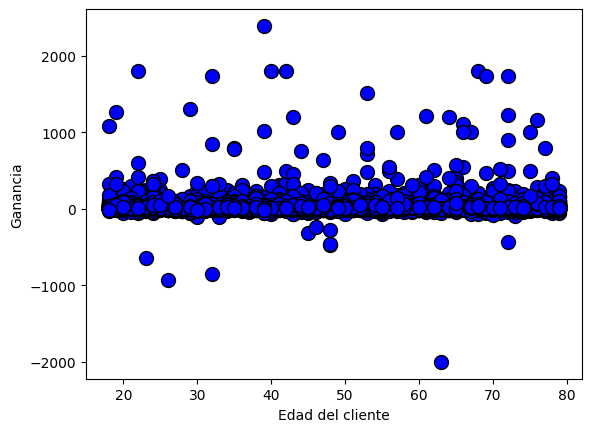

In [ ]:
plotData(X, y)

In [ ]:
# Ver cuántos registros tienen Revenue negativo
negativos = (y < 0).sum()
print(f'Registros con Revenue negativo: {negativos}')
print(f'Porcentaje: {negativos/m*100:.1f}%')

Registros con Revenue negativo: 574
Porcentaje: 3.3%


In [ ]:
# Ver estadísticas básicas del dataset
print(f'Número de ejemplos: {m}')
print(f'Customer_Age - Min: {X.min():.0f}, Max: {X.max():.0f}, Promedio: {X.mean():.1f}')
print(f'Revenue      - Min: {y.min():.2f}, Max: {y.max():.2f}, Promedio: {y.mean():.2f}')

Número de ejemplos: 17639
Customer_Age - Min: 18, Max: 79, Promedio: 48.3
Revenue      - Min: -1998.49, Max: 2386.80, Promedio: 20.12


In [ ]:
def plotData(x, y):
    fig = pyplot.figure()
    pyplot.plot(x, y, 'ro', ms=5, mec='k', alpha=0.2)  # alpha = transparencia
    pyplot.ylabel('Ganancia en $')
    pyplot.xlabel('Edad del cliente')

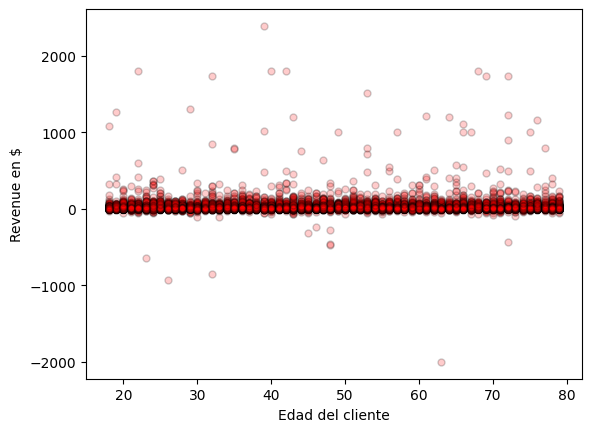

In [ ]:
plotData(X, y)

In [ ]:
# Agrega una columna de unos a X. La funcion stack de numpy une matrices a lo largo de un eje dado.
# El primer eje (eje = 0) se refiere a filas (ejemplos de entrenamiento)
# y el segundo eje (eje = 1) se refiere a columnas (características).

X = np.stack([np.ones(m), X], axis=1)

In [ ]:
print(X)

[[ 1. 26.]
 [ 1. 29.]
 [ 1. 33.]
 ...
 [ 1. 55.]
 [ 1. 45.]
 [ 1. 45.]]


## Función de Costo

La función de costo mide qué tan mal predice el modelo.
Utiliza el error cuadrático medio entre los valores predichos
y los valores reales. Mientras menor sea el costo, mejor predice el modelo.

In [ ]:
def calcularCosto(X, y, theta):
    # inicializa algunos valores importantes
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    # h = np.dot(X, theta)
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [ ]:
J = calcularCosto(X, y, theta=np.array([0.0, 0.0]))
print('Con theta = [0, 0] \n Costo calculado = %.2f' % J)
# print('Valor de costo esperado (aproximadamente) 32.07\n')

# pruebas adicionales de la función de costes
J = calcularCosto(X, y, theta=np.array([0.5, 0.5]))
print('Con theta = [0.5, 0.5]\n Costo calculado = %.2f' % J)
# print('Valor de costo esperado (aproximadamente)  54.24')

J = calcularCosto(X, y, theta=np.array([0.6, 0.6]))
print('Con theta = [0.6, 0.6]\n Costo calculado = %.2f' % J)

J = calcularCosto(X, y, theta=np.array([0.7, 0.7]))
print('Con theta = [0.7, 0.7]\n Costo calculado = %.2f' % J)

J = calcularCosto(X, y, theta=np.array([0.8, 0.8]))
print('Con theta = [0.8, 0.8]\n Costo calculado = %.2f' % J)

J = calcularCosto(X, y, theta=np.array([0.75,0.75]))
print('Con theta = [0.75, 0.75]\n Costo calculado = %.2f' % J)

Con theta = [0, 0] 
 Costo calculado = 2470.75
Con theta = [0.5, 0.5]
 Costo calculado = 2313.97
Con theta = [0.6, 0.6]
 Costo calculado = 2365.10
Con theta = [0.7, 0.7]
 Costo calculado = 2443.72
Con theta = [0.8, 0.8]
 Costo calculado = 2549.84
Con theta = [0.75, 0.75]
 Costo calculado = 2493.34


## Gradient Descent

Algoritmo que ajusta automáticamente los parámetros theta para minimizar
el costo. Se utilizó alpha=0.0001 y 30,000 iteraciones debido a que
los valores de Revenue son grandes. El modelo encontró θ₀=5.68 y θ₁=0.27,
indicando que por cada año adicional de edad el revenue aumenta $0.27 que se ve mas adelante.

In [ ]:
def gradientDescent(X, y, theta, alpha, num_iters):
        # Inicializa algunos valores importantes
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    # hace una copia de theta, para evitar cambiar la matriz original,
    # ya que las matrices numpy se pasan por referencia a las funciones

    theta = theta.copy()

    J_history = [] # Lista que se utiliza para almacenar el costo en cada iteración

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        # save the cost J in every iteration
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

In [ ]:
theta = np.zeros(2)      # theta inicial = [0, 0]
# Prueba estos valores de alpha uno por uno
theta_inicial = np.zeros(2)
num_iters = 30000

for alpha in [0.001, 0.0001, 0.00001]:
    theta, J_history = gradientDescent(X, y, theta_inicial, alpha, num_iters)
    print(f'Alpha: {alpha} → Costo final: {J_history[-1]:.2f} → Theta: {theta}')

/tmp/ipykernel_287/2596426485.py:7: RuntimeWarning: overflow encountered in square
  J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
/tmp/ipykernel_287/1666081048.py:13: RuntimeWarning: invalid value encountered in subtract
  theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)


Alpha: 0.001 → Costo final: nan → Theta: [nan nan]
Alpha: 0.0001 → Costo final: 2278.51 → Theta: [5.67867585 0.2664177 ]
Alpha: 1e-05 → Costo final: 2287.89 → Theta: [0.669973   0.35767008]


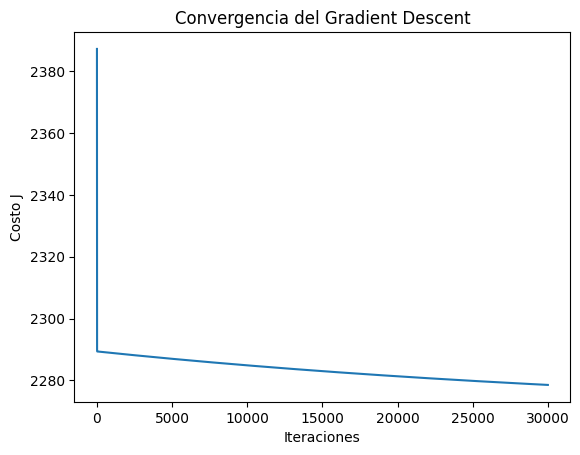

In [ ]:
theta_inicial = np.zeros(2)
alpha = 0.0001
num_iters = 30000

theta, J_history = gradientDescent(X, y, theta_inicial, alpha, num_iters)

# Grafica 1: Convergencia
pyplot.figure()
pyplot.plot(J_history)
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Gradient Descent')
pyplot.show()

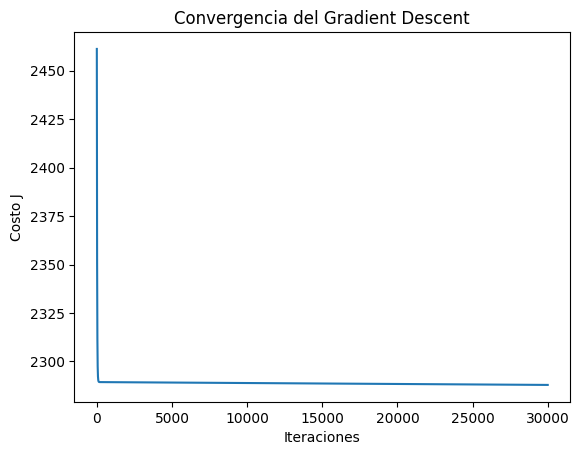

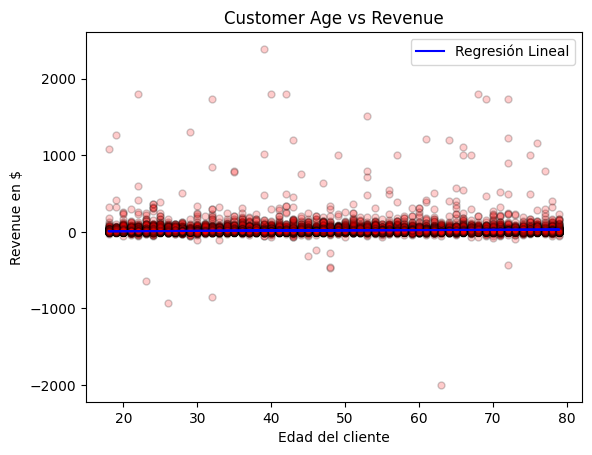

In [ ]:
theta_inicial = np.zeros(2)
alpha = 0.00001
num_iters = 30000

theta, J_history = gradientDescent(X, y, theta_inicial, alpha, num_iters)

# Grafica 1: Convergencia
pyplot.figure()
pyplot.plot(J_history)
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Gradient Descent')
pyplot.show()

# Grafica 2: Datos + línea de regresión
plotData(X[:, 1], y)
pyplot.plot(X[:, 1], np.dot(X, theta), '-b', label='Regresión Lineal')
pyplot.legend()
pyplot.title('Customer Age vs Revenue')
pyplot.show()

## Predicciones

Se realizan predicciones de Revenue para diferentes edades de clientes
usando los parámetros theta encontrados por la gradiente descendiente.

In [ ]:
# Predecir Revenue para diferentes edades
edades = [10,20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

for edad in edades:
    prediccion = np.dot([1, edad], theta)
    print(f'Para un cliente de {edad} años → Ganancia predicha: ${prediccion:.2f}')

Para un cliente de 10 años → Ganancia predicha: $4.25
Para un cliente de 20 años → Ganancia predicha: $7.82
Para un cliente de 30 años → Ganancia predicha: $11.40
Para un cliente de 40 años → Ganancia predicha: $14.98
Para un cliente de 50 años → Ganancia predicha: $18.55
Para un cliente de 60 años → Ganancia predicha: $22.13
Para un cliente de 70 años → Ganancia predicha: $25.71
Para un cliente de 80 años → Ganancia predicha: $29.28
Para un cliente de 90 años → Ganancia predicha: $32.86
Para un cliente de 100 años → Ganancia predicha: $36.44
Para un cliente de 110 años → Ganancia predicha: $40.01
Para un cliente de 120 años → Ganancia predicha: $43.59


## Visualización del mínimo

Se grafican la superficie 3D y el contorno del costo para visualizar
el mínimo encontrado por gradient descent. El punto rojo en el contorno
indica los valores óptimos de θ₀ y θ₁.

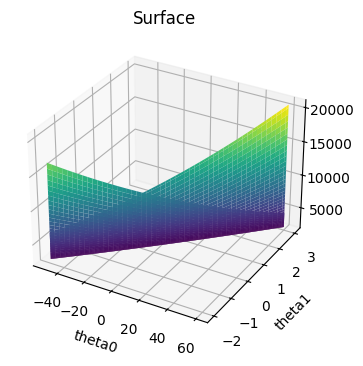

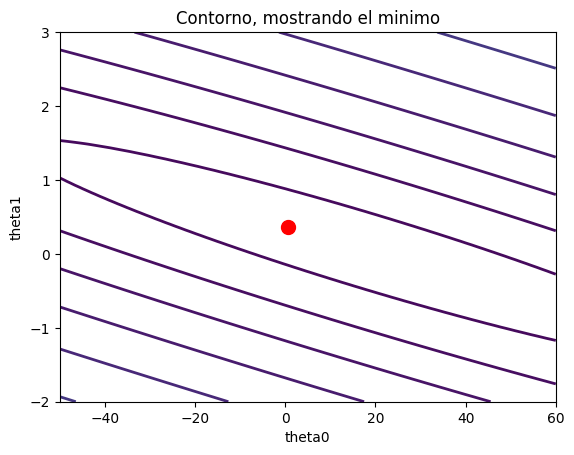

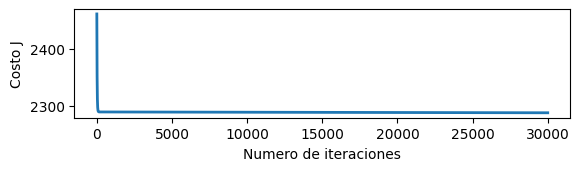

In [ ]:
# Cuadrícula centrada en tu theta encontrado
theta0_vals = np.linspace(-50, 60, 100)   # centrado cerca de 5.68
theta1_vals = np.linspace(-2, 3, 100)     # centrado cerca de 0.27

# Recalcular J_vals
J_vals = np.zeros((theta0_vals.shape[0], theta1_vals.shape[0]))

for i, theta0 in enumerate(theta0_vals):
    for j, theta1 in enumerate(theta1_vals):
        J_vals[i, j] = calcularCosto(X, y, [theta0, theta1])

J_vals = J_vals.T

# graficar la superficie
fig = pyplot.figure(figsize=(4, 15))
ax = fig.add_subplot(311, projection='3d')
ax.plot_surface(theta0_vals, theta1_vals, J_vals, cmap='viridis')
pyplot.xlabel('theta0')
pyplot.ylabel('theta1')
pyplot.title('Surface')

# Graficar contorno
pyplot.figure()
pyplot.contour(theta0_vals, theta1_vals, J_vals,
               linewidths=2, cmap='viridis',
               levels=np.logspace(2, 5, 20))  # ← niveles ajustados a tu costo (~2278)
pyplot.xlabel('theta0')
pyplot.ylabel('theta1')
pyplot.plot(theta[0], theta[1], 'ro', ms=10, lw=2)
pyplot.title('Contorno, mostrando el minimo')
pyplot.show()


# Grafica la convergencia del costo
ax = pyplot.subplot(313)
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

pass